# Week 3: Python & Data Wrangling
**Skill Nexis Internship**

### Topics covered
- Python basics: data structures, functions and scripting
- Pandas: reading data, filtering, cleaning and merging
- Data visualization: Matplotlib and Seaborn
- Missing-value handling and new columns

**Dataset:** Global Superstore sales data used in the Week 1 project workbook.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

FILE = "Skill_Nexis_Week1_Sales_Performance_Project.xlsx"
df = pd.read_excel(FILE, sheet_name="Cleaned Data")

print("Rows:", len(df))
print("Columns:", len(df.columns))
df.head()


Rows: 51290
Columns: 25


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Postal Code,City,State,Country,Region,Market,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority,Year
0,40098,CA-2014-AB10015140-41954,2014-11-11,2014-11-13,First Class,AB-100151402,Aaron Bergman,Consumer,73120.0,Oklahoma City,Oklahoma,United States,Central US,USCA,TEC-PH-5816,Technology,Phones,Samsung Convoy 3,221.980,2,0.0,62.1544,40.77,High,2014
1,26341,IN-2014-JR162107-41675,2014-02-05,2014-02-07,Second Class,JR-162107,Justin Ritter,Corporate,NaN,Wollongong,New South Wales,Australia,Oceania,Asia Pacific,FUR-CH-5379,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical,2014
2,25330,IN-2014-CR127307-41929,2014-10-17,2014-10-18,First Class,CR-127307,Craig Reiter,Consumer,NaN,Brisbane,Queensland,Australia,Oceania,Asia Pacific,TEC-PH-5356,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium,2014
3,13524,ES-2014-KM1637548-41667,2014-01-28,2014-01-30,First Class,KM-1637548,Katherine Murray,Home Office,NaN,Berlin,Berlin,Germany,Western Europe,Europe,TEC-PH-5267,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium,2014
4,47221,SG-2014-RH9495111-41948,2014-11-05,2014-11-06,Same Day,RH-9495111,Rick Hansen,Consumer,NaN,Dakar,Dakar,Senegal,Western Africa,Africa,TEC-CO-6011,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical,2014


## 1. Explore the dataset

In [2]:
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isna().sum().sort_values(ascending=False).head(10))


Shape: (51290, 25)

Data types:
Row ID                     int64
Order ID                  object
Order Date        datetime64[ns]
Ship Date         datetime64[ns]
Ship Mode                 object
Customer ID               object
Customer Name             object
Segment                   object
Postal Code              float64
City                      object
State                     object
Country                   object
Region                    object
Market                    object
Product ID                object
Category                  object
Sub-Category              object
Product Name              object
Sales                    float64
Quantity                   int64
Discount                 float64
Profit                   float64
Shipping Cost            float64
Order Priority            object
Year                       int64
dtype: object

Missing values:
Postal Code      41296
Row ID               0
Order ID             0
Ship Date            0
Order Date          

## 2. Data cleaning

In [3]:
data = df.copy()

# Remove duplicate rows
duplicate_rows = data.duplicated().sum()
data = data.drop_duplicates()

# Convert date and numeric columns to correct data types
data["Order Date"] = pd.to_datetime(data["Order Date"], errors="coerce")
data["Ship Date"] = pd.to_datetime(data["Ship Date"], errors="coerce")

for col in ["Sales", "Quantity", "Discount", "Profit", "Shipping Cost", "Postal Code"]:
    data[col] = pd.to_numeric(data[col], errors="coerce")

# Postal Code has many missing values; 0 is used as an explicit missing-code marker
missing_postal = data["Postal Code"].isna().sum()
data["Postal Code"] = data["Postal Code"].fillna(0)

# Create useful columns
data["Year"] = data["Order Date"].dt.year
data["Sales_Per_Unit"] = data["Sales"] / data["Quantity"].replace(0, np.nan)
data["Profit_Margin_%"] = np.where(
    data["Sales"] != 0, data["Profit"] / data["Sales"] * 100, 0
)
data["Sales_Level"] = np.where(
    data["Sales"] >= 1000, "High",
    np.where(data["Sales"] >= 500, "Medium", "Low")
)

print("Duplicate rows removed:", duplicate_rows)
print("Missing Postal Code values handled:", missing_postal)
print("Rows after cleaning:", len(data))
data.head()


Duplicate rows removed: 0
Missing Postal Code values handled: 41296
Rows after cleaning: 51290


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Postal Code,City,State,Country,Region,Market,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority,Year,Sales_Per_Unit,Profit_Margin_%,Sales_Level
0,40098,CA-2014-AB10015140-41954,2014-11-11,2014-11-13,First Class,AB-100151402,Aaron Bergman,Consumer,73120.0,Oklahoma City,Oklahoma,United States,Central US,USCA,TEC-PH-5816,Technology,Phones,Samsung Convoy 3,221.980,2,0.0,62.1544,40.77,High,2014,110.990,28.000000,Low
1,26341,IN-2014-JR162107-41675,2014-02-05,2014-02-07,Second Class,JR-162107,Justin Ritter,Corporate,0.0,Wollongong,New South Wales,Australia,Oceania,Asia Pacific,FUR-CH-5379,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical,2014,412.155,-7.784693,High
2,25330,IN-2014-CR127307-41929,2014-10-17,2014-10-18,First Class,CR-127307,Craig Reiter,Consumer,0.0,Brisbane,Queensland,Australia,Oceania,Asia Pacific,TEC-PH-5356,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium,2014,575.019,17.776630,High
3,13524,ES-2014-KM1637548-41667,2014-01-28,2014-01-30,First Class,KM-1637548,Katherine Murray,Home Office,0.0,Berlin,Berlin,Germany,Western Europe,Europe,TEC-PH-5267,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium,2014,578.502,-3.337586,High
4,47221,SG-2014-RH9495111-41948,2014-11-05,2014-11-06,Same Day,RH-9495111,Rick Hansen,Consumer,0.0,Dakar,Dakar,Senegal,Western Africa,Africa,TEC-CO-6011,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical,2014,354.120,10.996272,High


## 3. Filtering and selecting data

In [4]:
high_sales = data.loc[
    data["Sales"] >= 1000,
    ["Order ID", "Customer Name", "Category", "Sales", "Profit"]
].sort_values("Sales", ascending=False)

print("Orders with Sales >= 1000:", len(high_sales))
high_sales.head(10)


Orders with Sales >= 1000: 2626


,Order ID,Customer Name,Category,Sales,Profit
47114,CA-2012-SM20320140-40985,Sean Miller,Technology,22638.480,-1811.0784
49003,CA-2014-TC20980140-41915,Tamara Chand,Technology,17499.950,8399.9760
44248,CA-2015-RB19360140-42087,Raymond Buch,Technology,13999.960,6719.9808
49940,CA-2015-TA21385140-42300,Tom Ashbrook,Technology,11199.968,3919.9888
25238,CA-2015-HL15040140-42326,Hunter Lopez,Technology,10499.970,5039.9856
419,CA-2014-AB10105140-41991,Adrian Barton,Office Supplies,9892.740,4946.3700
46295,CA-2012-SC20095140-41174,Sanjit Chand,Office Supplies,9449.950,4630.4755
6422,US-2014-BS11365140-41746,Bill Shonely,Technology,9099.930,2365.9818
46386,CA-2014-SE20110140-41672,Sanjit Engle,Technology,8749.950,2799.9840
11063,CA-2014-CC12370140-41783,Christopher Conant,Technology,8399.976,1119.9968


## 4. Grouping and aggregation with Pandas

In [5]:
sales_by_category = (
    data.groupby("Category", as_index=False)["Sales"]
    .sum()
    .sort_values("Sales", ascending=False)
)

sales_by_year = (
    data.groupby("Year", as_index=False)["Sales"]
    .sum()
    .sort_values("Year")
)

print("Sales by Category")
display(sales_by_category)

print("Sales by Year")
display(sales_by_year)


Sales by Category


,Category,Sales
2,Technology,4.744557e+06
0,Furniture,4.110452e+06
1,Office Supplies,3.787493e+06


Sales by Year


,Year,Sales
0,2012,2.259451e+06
1,2013,2.677439e+06
2,2014,3.405746e+06
3,2015,4.299866e+06


## 5. Merging data

In [6]:
customer_sales = (
    data.groupby("Customer ID", as_index=False)
    .agg(Total_Sales=("Sales", "sum"),
         Order_Count=("Order ID", "nunique"))
)

customer_info = data[
    ["Customer ID", "Customer Name", "Segment"]
].drop_duplicates("Customer ID")

merged_customers = customer_info.merge(
    customer_sales,
    on="Customer ID",
    how="left"
)

merged_customers.sort_values("Total_Sales", ascending=False).head(10)


,Customer ID,Customer Name,Segment,Total_Sales,Order_Count
16652,SM-203201408,Sean Miller,Home Office,23669.196,2
17012,TC-209801402,Tamara Chand,Corporate,18437.138,2
16072,RB-193601404,Raymond Buch,Consumer,14345.276,2
17186,TA-213851406,Tom Ashbrook,Home Office,13723.498,2
336,AB-101051402,Adrian Barton,Consumer,12181.594,5
29,DP-131057,Dave Poirier,Corporate,11864.139,5
86,FH-1436582,Fred Hopkins,Corporate,10880.180,4
3733,BM-111401402,Becky Martin,Consumer,10539.896,1
11728,HL-150401406,Hunter Lopez,Consumer,10522.550,2
252,CA-1277558,Cynthia Arntzen,Consumer,10463.010,3


## 6. Top 10 customers

In [7]:
top_customers = (
    data.groupby("Customer Name", as_index=False)
    .agg(
        Total_Sales=("Sales", "sum"),
        Orders=("Order ID", "nunique"),
        Avg_Order_Value=("Sales", "mean")
    )
    .sort_values("Total_Sales", ascending=False)
    .head(10)
)

top_customers


,Customer Name,Total_Sales,Orders,Avg_Order_Value
759,Tom Ashbrook,40488.07080,29,506.100885
732,Tamara Chand,37457.33300,36,425.651511
313,Greg Tran,35550.95428,33,408.631658
157,Christopher Conant,35187.07640,39,482.014745
688,Sean Miller,35170.93296,28,703.418659
73,Bart Watters,32310.44650,45,336.567151
559,Natalie Fritzler,31781.25850,43,334.539563
290,Fred Hopkins,30400.67452,39,370.739933
347,Jane Waco,30288.45030,40,403.846004
335,Hunter Lopez,30243.56658,24,570.633332


## 7. Matplotlib: Sales by Category

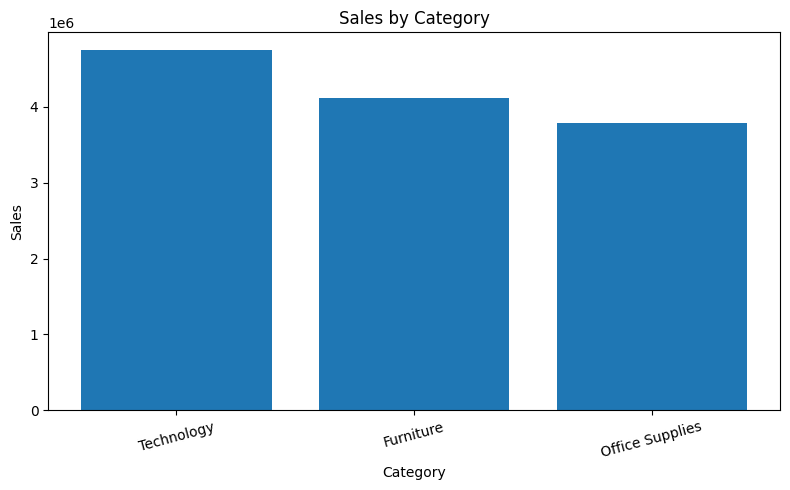

In [8]:
plt.figure(figsize=(8, 5))
plt.bar(sales_by_category["Category"], sales_by_category["Sales"])
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


## 8. Matplotlib: Yearly Sales Trend

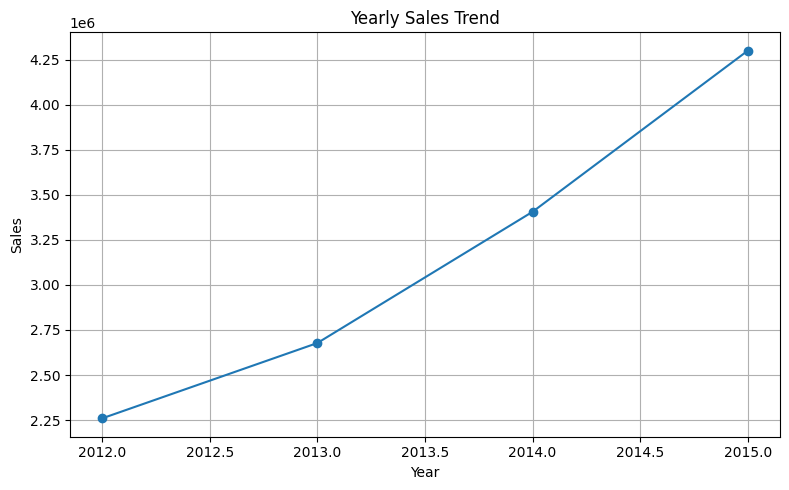

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(sales_by_year["Year"], sales_by_year["Sales"], marker="o")
plt.title("Yearly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.grid(True)
plt.tight_layout()
plt.show()


## 9. Seaborn: Sales distribution by category

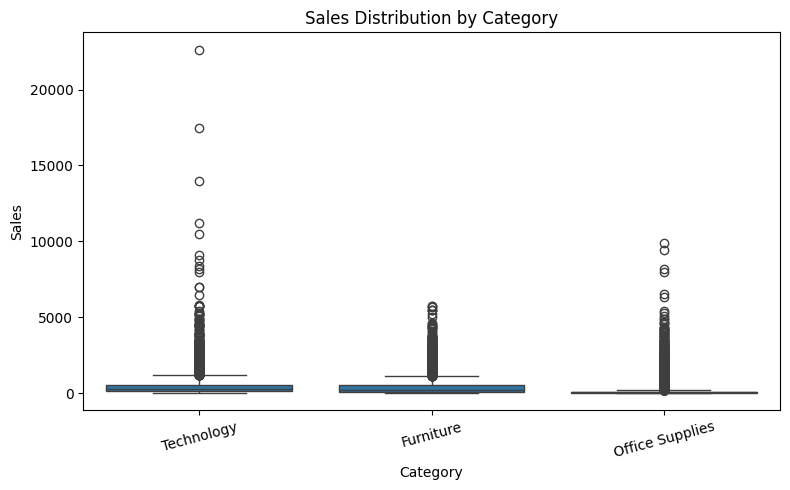

In [10]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=data, x="Category", y="Sales")
plt.title("Sales Distribution by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


## Conclusion
- The dataset was loaded and explored using Pandas.
- Duplicate rows were checked and date/numeric columns were converted to appropriate types.
- Missing Postal Code values were handled.
- New columns such as `Sales_Per_Unit`, `Profit_Margin_%`, `Year`, and `Sales_Level` were created.
- Filtering, grouping, aggregation and merging were demonstrated.
- Matplotlib and Seaborn were used to visualize category sales, yearly trends and sales distributions.
